In [ ]:
from sklearn import datasets 
from sklearn.svm import LinearSVC
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [ ]:
#Load Iris datset

iris = datasets.load_iris()

x = iris["data"][: , (2 , 3)] #Petal length , Petal width
y = (iris["target"] == 2).astype(int) #Iris Virginica

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [11]:
iris_pipeline = Pipeline([
    ("scaler" , StandardScaler()),
    ("linear_svc" , LinearSVC(C = 1 , loss="hinge"))
])

In [12]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [13]:
iris_pipeline.fit(x_scaled , y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [24]:
iris_pipeline.predict([[5 , 4]])

array([1])

In [25]:
#Implementing using SGDclassifier 
from sklearn.linear_model import SGDClassifier

m  = len(x)
c = 0.1

iris_pipeline_1 = Pipeline([
    ("standad_Scaler" , StandardScaler()),
    ("stiochastic " , SGDClassifier(loss= "hinge" , alpha= 1/(m*c)))
])

In [26]:
iris_pipeline_1.fit(x , y)
iris_pipeline_1.predict([[5 , 4]])

array([1])

In [36]:
#non-linear SVM classification
from sklearn.datasets import make_moons 
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

x_1 , y_1 = make_moons(n_samples=100 , random_state=42 , noise= 0.15)

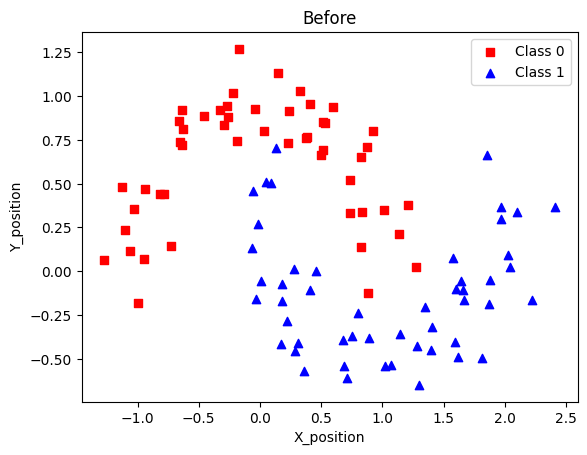

In [44]:
plt.scatter(x_1[y_1==0][: , 0] , x_1[y_1==0][: , 1] , label = "Class 0"  , color = "red" , marker="s")
plt.scatter(x_1[y_1 == 1][: , 0] , x_1[y_1==1][: , 1] , label = "Class 1" , color = "blue" , marker="^")
plt.legend()
plt.xlabel("X_position")
plt.ylabel("Y_position")
plt.title("Before")
plt.show()

In [47]:
moon_pipeline = Pipeline([
    ("scaler" , StandardScaler()),
    ("poly_features" , PolynomialFeatures(degree= 3)),
    ("svm" , LinearSVC(C = 10 , loss= "hinge"))
])

moon_pipeline.fit(x_1 , y_1)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly_features', PolynomialFeatures(degree=3)),
                ('svm', LinearSVC(C=10, loss='hinge'))])